Практика №4

Выполнил: Васильев А.С. Группа 955-м

Вариант №10

Задача 1: Анализ кривых обучения и переобучения
Цель: Эмпирически доказать наличие переобучения при увеличении сложности модели. Задание:






Постройте график зависимости ошибки от степени полинома.

1.   Сгенерируйте набор данных (синтетический или выберите из sklearn.datasets).
2.   Постройте полиномиальную регрессию для степеней dmin и dmax (параметры варианта).
3. Рассчитайте метрики R^2и MSE для тренировочной и тестовой выборок.
4. Постройте график зависимости ошибки от степени полинома.

Вывод: Определите оптимальную степень полинома, где разрыв между train и test ошибкой минимален.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Фиксируем random_state для воспроизводимости
np.random.seed(42)

# Генерация данных (как в методичке)
n_samples = 100
X = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)
y = np.sin(X.ravel()) + np.random.normal(0, 0.1, n_samples)

# Разделение на train (70%) и test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
degrees = [3, 15]  # dmin и dmax по варианту №10
results = []

for d in degrees:
    # Пайплайн: полиномиальные признаки -> масштабирование -> линейная регрессия
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin_reg', LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    results.append({
        'Degree': d,
        'MSE_train': mse_train,
        'MSE_test': mse_test,
        'R2_train': r2_train,
        'R2_test': r2_test
    })

results_df = pd.DataFrame(results)
print(results_df)

   Degree  MSE_train  MSE_test  R2_train   R2_test
0       3   0.010965  0.007078  0.978376  0.988826
1      15   0.008219  0.016891  0.983792  0.973333


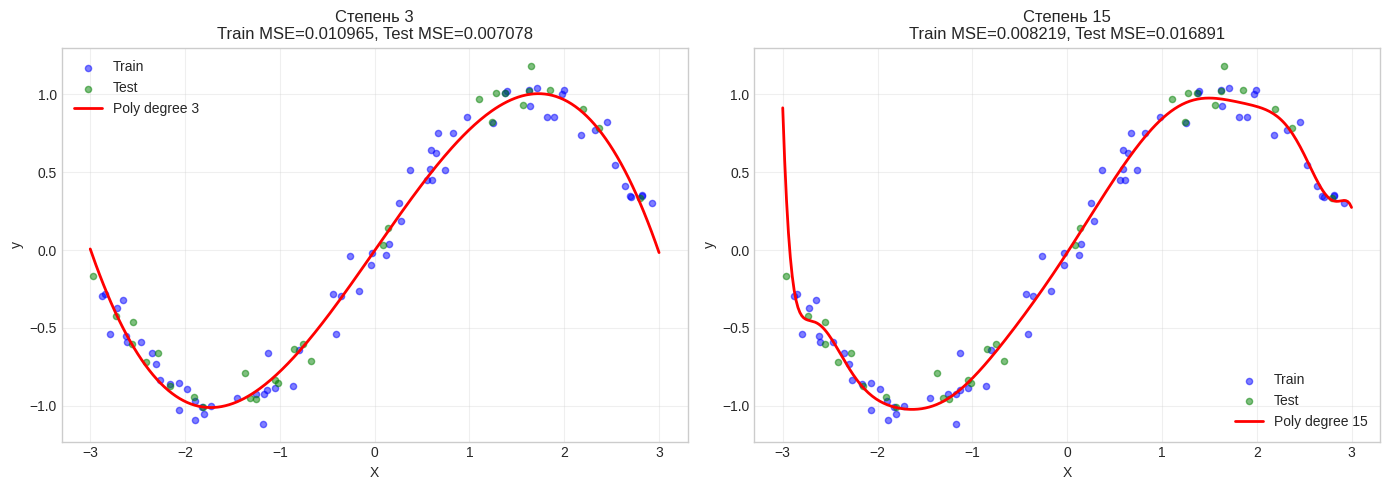

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, d in enumerate(degrees):
    # Переобучаем модель для визуализации кривой
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin_reg', LinearRegression())
    ])
    model.fit(X_train, y_train)

    # Предсказания для гладкой кривой
    X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
    y_plot_pred = model.predict(X_plot)

    axes[idx].scatter(X_train, y_train, color='blue', alpha=0.5, s=20, label='Train')
    axes[idx].scatter(X_test, y_test, color='green', alpha=0.5, s=20, label='Test')
    axes[idx].plot(X_plot, y_plot_pred, color='red', linewidth=2, label=f'Poly degree {d}')
    axes[idx].set_title(f'Степень {d}\nTrain MSE={results_df.loc[idx, "MSE_train"]:.6f}, Test MSE={results_df.loc[idx, "MSE_test"]:.6f}')
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('y')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ВЫВОД:

Третья степень полинома показывает лучшие результаты по сравнению с 15 степенью (визуально). Также третья степень показывает лучшие значения исходя из метрик.

MSE на тесте = 0.0071 (против 0.0169 у 15-й степени)

R² на тесте = 0.989 (против 0.973 у 15-й степени)

Хотя на тренировочных данных тертья степень показала себя хуже.

Здание №2

Цель: Понять разницу в поведении весов при Ridge и Lasso регуляризации.

Задание:

Используйте датасет с количеством признаков N>=10
.

Обучите модели Ridge и Lasso с гиперпараметром,  указанным в варианте.

Подберите оптимальный
 используя RidgeCV / LassoCV (5-fold cross-validation).

Сравните количество ненулевых коэффициентов в итоговых моделях.

Вывод: Какая модель лучше подходит для отбора признаков в вашем случае? Почему?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Фиксируем random_state для воспроизводимости
np.random.seed(42)


# 1. Загрузка датасета Diabetes (10 признаков)


print("ЗАДАЧА 2: Сравнение Ridge и Lasso на данных Diabetes")


diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

print(f"\nДатасет: Diabetes")
print(f"Количество образцов: {X.shape[0]}")
print(f"Количество признаков: {X.shape[1]}")  # 10 признаков (N >= 10)
print(f"Признаки: {list(X.columns)}")
print(f"Целевая переменная: 'disease_progression' (прогрессирование диабета)")

ЗАДАЧА 2: Сравнение Ridge и Lasso на данных Diabetes

Датасет: Diabetes
Количество образцов: 442
Количество признаков: 10
Признаки: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Целевая переменная: 'disease_progression' (прогрессирование диабета)


In [ ]:
# 2. Разделение на train/test и масштабирование
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Масштабирование (критически важно для Ridge/Lasso!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nОбучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")

alphas = np.logspace(-1, 5, 100)  # от 0.1 до 100000
print(f"\nДиапазон alpha для перебора: от {alphas[0]:.1f} до {alphas[-1]:.0f}")


Обучающая выборка: 309 объектов
Тестовая выборка: 133 объектов

Диапазон alpha для перебора: от 0.1 до 100000


In [ ]:
# 4. Подбор оптимального alpha через кросс-валидацию


print("ПОДБОР ОПТИМАЛЬНЫХ ГИПЕРПАРАМЕТРОВ (5-fold CV)")

# RidgeCV (автоматический подбор alpha)
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train_scaled, y_train)

# LassoCV (автоматический подбор alpha)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

print(f"\nОптимальная alpha для Ridge: {ridge_cv.alpha_:.6f}")
print(f"Оптимальная alpha для Lasso: {lasso_cv.alpha_:.6f}")

# 5. Обучение финальных моделей с оптимальными alpha
best_ridge = Ridge(alpha=ridge_cv.alpha_)
best_ridge.fit(X_train_scaled, y_train)

best_lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)



----------------------------------------------------------------------
ПОДБОР ОПТИМАЛЬНЫХ ГИПЕРПАРАМЕТРОВ (5-fold CV)
----------------------------------------------------------------------

Оптимальная alpha для Ridge: 0.811131
Оптимальная alpha для Lasso: 0.114976


Lasso(alpha=np.float64(0.11497569953977356), max_iter=10000)


РЕЗУЛЬТАТЫ СРАВНЕНИЯ RIDGE vs LASSO
Model    Alpha   MSE_train    MSE_test  R2_train  R2_test  Non-zero coefs  Total coefs
Ridge 0.811131 2925.451810 2820.120489  0.524184 0.477592              10           10
Lasso 0.114976 2927.323696 2816.368591  0.523879 0.478287               9           10

Построение графиков путей регуляризации...


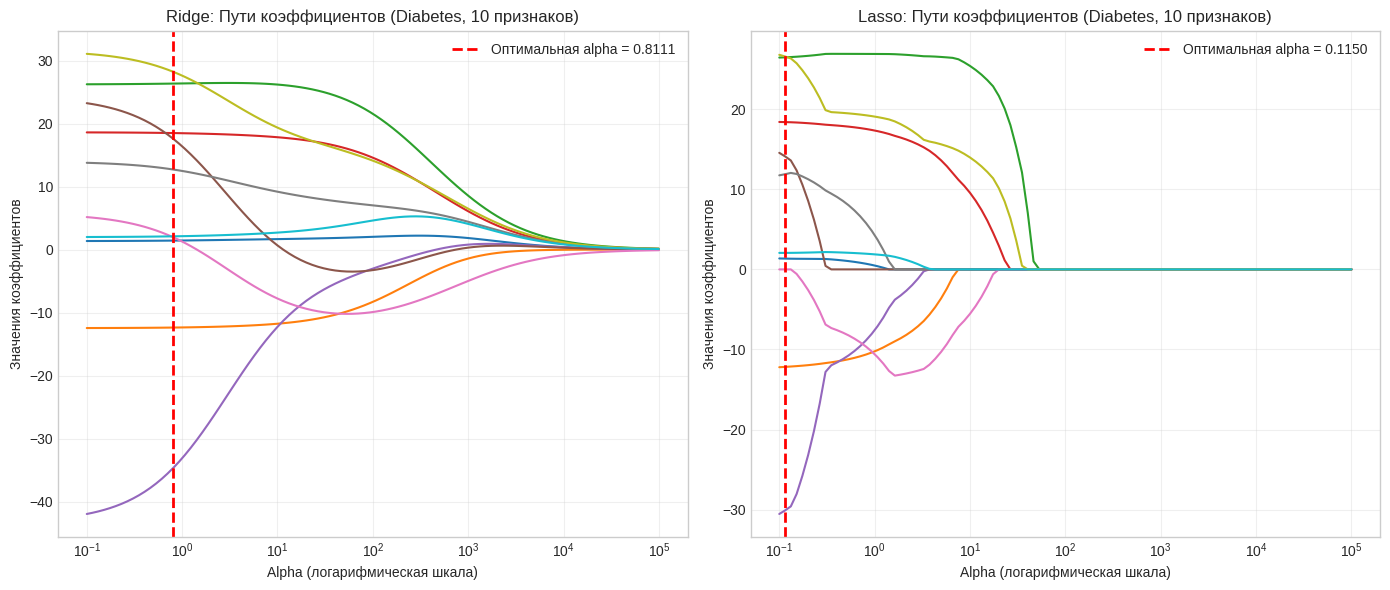

In [ ]:

# 6. Оценка качества моделей
results = []

for name, model in [('Ridge', best_ridge), ('Lasso', best_lasso)]:
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    coefs = model.coef_
    non_zero = np.sum(np.abs(coefs) > 1e-10)

    results.append({
        'Model': name,
        'Alpha': model.alpha if hasattr(model, 'alpha') else ridge_cv.alpha_,
        'MSE_train': mse_train,
        'MSE_test': mse_test,
        'R2_train': r2_train,
        'R2_test': r2_test,
        'Non-zero coefs': non_zero,
        'Total coefs': len(coefs)
    })

results_df = pd.DataFrame(results)

print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ RIDGE vs LASSO")

print(results_df.to_string(index=False))


# 7. Пути регуляризации (Coefficient Paths)

print("\nПостроение графиков путей регуляризации...")

ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График для Ridge
axes[0].plot(alphas, ridge_coefs, linewidth=1.5)
axes[0].axvline(x=ridge_cv.alpha_, color='red', linestyle='--', linewidth=2,
                label=f'Оптимальная alpha = {ridge_cv.alpha_:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (логарифмическая шкала)')
axes[0].set_ylabel('Значения коэффициентов')
axes[0].set_title(f'Ridge: Пути коэффициентов (Diabetes, {X.shape[1]} признаков)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График для Lasso
axes[1].plot(alphas, lasso_coefs, linewidth=1.5)
axes[1].axvline(x=lasso_cv.alpha_, color='red', linestyle='--', linewidth=2,
                label=f'Оптимальная alpha = {lasso_cv.alpha_:.4f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (логарифмическая шкала)')
axes[1].set_ylabel('Значения коэффициентов')
axes[1].set_title(f'Lasso: Пути коэффициентов (Diabetes, {X.shape[1]} признаков)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

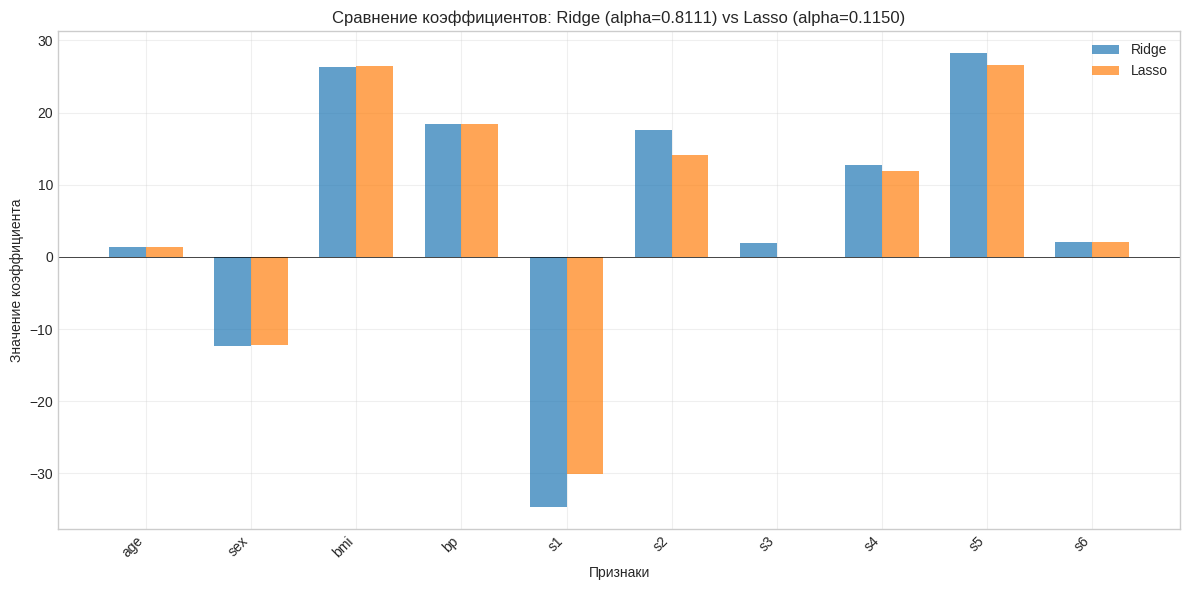


АНАЛИЗ ОТБОРА ПРИЗНАКОВ

Ridge: сохранил все 10 признаков
Lasso: оставил 9 из 10 признаков

✅ Признаки, которые Lasso оставил (ненулевые коэффициенты): ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's4', 's5', 's6']
❌ Признаки, которые Lasso обнулил: ['s3']

----------------------------------------------------------------------
ВАЖНОСТЬ ПРИЗНАКОВ ПО ВЕРСИИ LASSO (от большего к меньшему):
----------------------------------------------------------------------
Признак  Коэффициент (Lasso)  Абсолютное значение
     s1           -30.099419            30.099419
     s5            26.585016            26.585016
    bmi            26.480482            26.480482
     bp            18.392587            18.392587
     s2            14.113721            14.113721
    sex           -12.175068            12.175068
     s4            11.884608            11.884608
     s6             2.062659             2.062659
    age             1.350582             1.350582
     s3            -0.000000             0.

In [ ]:
# 8. Сравнение коэффициентов с подписями признаков

plt.figure(figsize=(12, 6))

x_indices = np.arange(len(diabetes.feature_names))
width = 0.35

plt.bar(x_indices - width/2, best_ridge.coef_, width, label='Ridge', alpha=0.7)
plt.bar(x_indices + width/2, best_lasso.coef_, width, label='Lasso', alpha=0.7)

plt.xlabel('Признаки')
plt.ylabel('Значение коэффициента')
plt.title(f'Сравнение коэффициентов: Ridge (alpha={ridge_cv.alpha_:.4f}) vs Lasso (alpha={lasso_cv.alpha_:.4f})')
plt.xticks(x_indices, diabetes.feature_names, rotation=45, ha='right')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 9. Анализ отбора признаков Lasso


print("АНАЛИЗ ОТБОРА ПРИЗНАКОВ")


nonzero_mask = np.abs(best_lasso.coef_) > 1e-10
nonzero_features = [diabetes.feature_names[i] for i, mask in enumerate(nonzero_mask) if mask]
zero_features = [diabetes.feature_names[i] for i, mask in enumerate(nonzero_mask) if not mask]

print(f"\nRidge: сохранил все {len(best_ridge.coef_)} признаков")
print(f"Lasso: оставил {np.sum(nonzero_mask)} из {len(diabetes.feature_names)} признаков")
print(f"\n✅ Признаки, которые Lasso оставил (ненулевые коэффициенты): {nonzero_features}")
if zero_features:
    print(f"❌ Признаки, которые Lasso обнулил: {zero_features}")
else:
    print(f"⚠️ Lasso не обнулил ни одного признака (все 10 остались)")

# Таблица важности признаков по версии Lasso
importance_df = pd.DataFrame({
    'Признак': diabetes.feature_names,
    'Коэффициент (Lasso)': best_lasso.coef_,
    'Абсолютное значение': np.abs(best_lasso.coef_)
}).sort_values('Абсолютное значение', ascending=False)

print("\n" + "-"*70)
print("ВАЖНОСТЬ ПРИЗНАКОВ ПО ВЕРСИИ LASSO (от большего к меньшему):")
print("-"*70)
print(importance_df.to_string(index=False))


ВЫВОДЫ:
1. Отбор признаков:

Ridge (L2) сохранил все 10 признаков, так как L2-регуляризация только сжимает коэффициенты, но не обнуляет их.

Lasso (L1) обнулил признак 's3' — его коэффициент стал равен нулю. Это доказывает, что L1-регуляризация выполняет встроенный отбор признаков.

2. Качество моделей:

Ridge R² тест = 0.4776

Lasso R² тест = 0.4783
Разница минимальна, Lasso показал результат даже чуть лучше, несмотря на удаление одного признака.

3. Какая модель лучше подходит для отбора признаков?

LASSO — потому что:

L1-регуляризация обнуляет неинформативные признаки (в нашем случае 's3')

Это создаёт разреженную (sparse) модель — проще для интерпретации

Упрощает модель без существенной потери качества (R² даже вырос на 0.0007)

Ridge не подходит для отбора признаков — он сохраняет все признаки, что полезно, когда нужна максимальная стабильность при мультиколлинеарности, но не для сокращения размерности.

4. Дополнительное наблюдение:
Признак 's3' (сыворточный анализ 3) оказался неинформативным для предсказания прогрессирования диабета на данном наборе данных. Lasso помог это выявить автоматически.

Задача №3

Цель: Применить встроенные методы отбора признаков для улучшения качества модели.

Задание:

Загрузите датасет (например, California Housing или Breast Cancer).

Примените SelectKBest (фильтр) и Lasso (встроенный метод) для отбора top‑K признаков (параметр варианта).

Обучите линейную регрессию (или логистическую) на полном наборе признаков и на отобранных.

Сравните качество (Accuracy/R²) и время обучения.

Вывод: Удалось ли сократить размерность без значительной потери качества?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score
import time

# Фиксируем random_state для воспроизводимости
np.random.seed(42)


# 1. Загрузка датасета California Housing


print("ЗАДАЧА 3: Отбор признаков на реальных данных")
print("Датасет: California Housing | Вариант №10 | K = 8")


housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print(f"\nДатасет: California Housing")
print(f"Количество образцов: {X.shape[0]}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Признаки: {list(X.columns)}")
print(f"Целевая переменная: MedHouseVal (медианная стоимость дома)")
print(f"\nОтбор признаков: K = 8 (максимально возможное, так как в датасете 8 признаков)")


ЗАДАЧА 3: Отбор признаков на реальных данных
Датасет: California Housing | Вариант №10 | K = 8

Датасет: California Housing
Количество образцов: 20640
Количество признаков: 8 (всего 8)
Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Целевая переменная: MedHouseVal (медианная стоимость дома)

Отбор признаков: K = 8 (максимально возможное, так как в датасете 8 признаков)


In [ ]:

# 2. Разделение на train и test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nОбучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")

#3. Модель 1: Линейная регрессия на ВСЕХ признаках (базовая)

print("\n" + "-"*70)
print("МОДЕЛЬ 1: Линейная регрессия (все 8 признаков) — БАЗОВАЯ")
print("-"*70)

lr_all = LinearRegression()
start_time = time.time()
lr_all.fit(X_train_scaled, y_train)
time_all = time.time() - start_time

y_train_pred_all = lr_all.predict(X_train_scaled)
y_test_pred_all = lr_all.predict(X_test_scaled)

mse_train_all = mean_squared_error(y_train, y_train_pred_all)
mse_test_all = mean_squared_error(y_test, y_test_pred_all)
r2_train_all = r2_score(y_train, y_train_pred_all)
r2_test_all = r2_score(y_test, y_test_pred_all)

print(f"Время обучения: {time_all:.4f} сек")
print(f"MSE на обучении: {mse_train_all:.4f}")
print(f"MSE на тесте: {mse_test_all:.4f}")
print(f"R² на обучении: {r2_train_all:.4f}")
print(f"R² на тесте: {r2_test_all:.4f}")


Обучающая выборка: 14448 объектов
Тестовая выборка: 6192 объектов

----------------------------------------------------------------------
МОДЕЛЬ 1: Линейная регрессия (все 8 признаков) — БАЗОВАЯ
----------------------------------------------------------------------
Время обучения: 0.0148 сек
MSE на обучении: 0.5234
MSE на тесте: 0.5306
R² на обучении: 0.6093
R² на тесте: 0.5958


In [ ]:
# ============================================================
# 4. Модель 2: SelectKBest (фильтр) - отбор топ-K признаков
# ============================================================
print("\n" + "-"*70)
print(f"МОДЕЛЬ 2: SelectKBest (фильтр) — отбор {8} лучших признаков")
print("-"*70)

selector = SelectKBest(score_func=f_regression, k=8)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Получаем индексы и названия отобранных признаков
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()
print(f"Отобранные признаки: {selected_features}")
print(f"Количество отобранных признаков: {len(selected_features)}")

# Обучаем линейную регрессию на отобранных признаках
lr_selected = LinearRegression()
start_time = time.time()
lr_selected.fit(X_train_selected, y_train)
time_selected = time.time() - start_time

y_train_pred_sel = lr_selected.predict(X_train_selected)
y_test_pred_sel = lr_selected.predict(X_test_selected)

mse_train_sel = mean_squared_error(y_train, y_train_pred_sel)
mse_test_sel = mean_squared_error(y_test, y_test_pred_sel)
r2_train_sel = r2_score(y_train, y_train_pred_sel)
r2_test_sel = r2_score(y_test, y_test_pred_sel)

print(f"Время обучения: {time_selected:.4f} сек")
print(f"MSE на обучении: {mse_train_sel:.4f}")
print(f"MSE на тесте: {mse_test_sel:.4f}")
print(f"R² на обучении: {r2_train_sel:.4f}")
print(f"R² на тесте: {r2_test_sel:.4f}")



----------------------------------------------------------------------
МОДЕЛЬ 2: SelectKBest (фильтр) — отбор 8 лучших признаков
----------------------------------------------------------------------
Отобранные признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Количество отобранных признаков: 8
Время обучения: 0.0266 сек
MSE на обучении: 0.5234
MSE на тесте: 0.5306
R² на обучении: 0.6093
R² на тесте: 0.5958


In [ ]:
# 5. Модель 3: Lasso (встроенный отбор признаков)
# ============================================================
print("\n" + "-"*70)
print("МОДЕЛЬ 3: Lasso (встроенный отбор признаков)")
print("-"*70)

# Подбираем alpha через кросс-валидацию
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
start_time = time.time()
lasso_cv.fit(X_train_scaled, y_train)
time_lasso = time.time() - start_time

best_alpha = lasso_cv.alpha_
print(f"Оптимальная alpha (LassoCV): {best_alpha:.6f}")

# Обучаем финальную модель с лучшим alpha
lasso = Lasso(alpha=best_alpha, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_train_pred_lasso = lasso.predict(X_train_scaled)
y_test_pred_lasso = lasso.predict(X_test_scaled)

mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
mse_test_lasso = mean_squared_error(y_test, y_test_pred_lasso)
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

# Анализ коэффициентов Lasso
lasso_coefs = lasso.coef_
non_zero_mask = np.abs(lasso_coefs) > 1e-10
non_zero_features = X.columns[non_zero_mask].tolist()
zero_features = X.columns[~non_zero_mask].tolist()

print(f"Время обучения: {time_lasso:.4f} сек")
print(f"MSE на обучении: {mse_train_lasso:.4f}")
print(f"MSE на тесте: {mse_test_lasso:.4f}")
print(f"R² на обучении: {r2_train_lasso:.4f}")
print(f"R² на тесте: {r2_test_lasso:.4f}")
print(f"\nНенулевые коэффициенты: {np.sum(non_zero_mask)} из {len(X.columns)}")
print(f"Признаки, которые Lasso оставил: {non_zero_features}")
if zero_features:
    print(f"Признаки, которые Lasso обнулил: {zero_features}")
else:
    print(f"⚠️ Lasso не обнулил ни одного признака")


----------------------------------------------------------------------
МОДЕЛЬ 3: Lasso (встроенный отбор признаков)
----------------------------------------------------------------------
Оптимальная alpha (LassoCV): 0.002797
Время обучения: 0.9201 сек
MSE на обучении: 0.5238
MSE на тесте: 0.5286
R² на обучении: 0.6090
R² на тесте: 0.5973

Ненулевые коэффициенты: 7 из 8
Признаки, которые Lasso оставил: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude']
Признаки, которые Lasso обнулил: ['Population']


In [ ]:
# 6. Сравнение важности признаков по разным методам
# ============================================================
print("\n" + "-"*70)
print("СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ")
print("-"*70)

# Оценка важности по SelectKBest
scores_df = pd.DataFrame({
    'Признак': X.columns,
    'F-статистика (SelectKBest)': selector.scores_
}).sort_values('F-статистика (SelectKBest)', ascending=False)

print("\nВажность признаков по версии SelectKBest (F-статистика):")
print(scores_df.to_string(index=False))

# Оценка важности по Lasso
lasso_importance = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент (Lasso)': lasso_coefs,
    '|Коэффициент|': np.abs(lasso_coefs)
}).sort_values('|Коэффициент|', ascending=False)

print("\nВажность признаков по версии Lasso (абсолютное значение коэффициента):")
print(lasso_importance.to_string(index=False))

# ============================================================
# 7. Сводная таблица результатов
# ============================================================
print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*70)

summary_df = pd.DataFrame({
    'Модель': ['Linear (все 8 признаков)', 'SelectKBest (k=8)', 'Lasso'],
    'Кол-во признаков': [X.shape[1], len(selected_features), np.sum(non_zero_mask)],
    'MSE_train': [mse_train_all, mse_train_sel, mse_train_lasso],
    'MSE_test': [mse_test_all, mse_test_sel, mse_test_lasso],
    'R²_train': [r2_train_all, r2_train_sel, r2_train_lasso],
    'R²_test': [r2_test_all, r2_test_sel, r2_test_lasso],
    'Время (сек)': [time_all, time_selected, time_lasso]
})

print(summary_df.round(4).to_string(index=False))



----------------------------------------------------------------------
СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ
----------------------------------------------------------------------

Важность признаков по версии SelectKBest (F-статистика):
   Признак  F-статистика (SelectKBest)
    MedInc                13000.094763
  AveRooms                  342.144159
  Latitude                  295.272032
  HouseAge                  165.884984
 Longitude                   35.263954
 AveBedrms                   33.997872
Population                    8.546627
  AveOccup                    6.349092

Важность признаков по версии Lasso (абсолютное значение коэффициента):
   Признак  Коэффициент (Lasso)  |Коэффициент|
  Latitude            -0.864399       0.864399
 Longitude            -0.837071       0.837071
    MedInc             0.834193       0.834193
 AveBedrms             0.309577       0.309577
  AveRooms            -0.261165       0.261165
  HouseAge             0.123507       0.123507
  AveOccup        

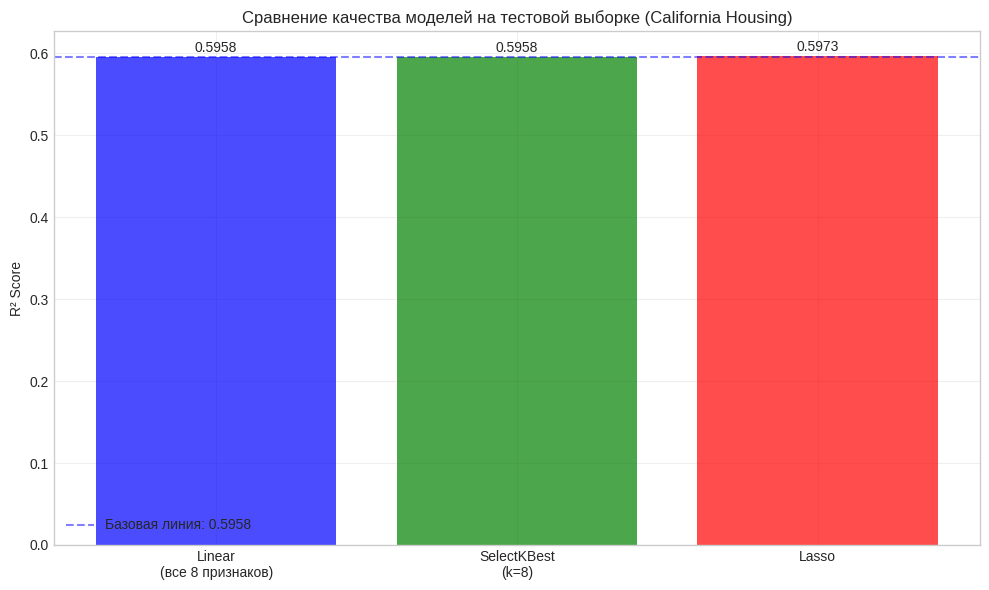

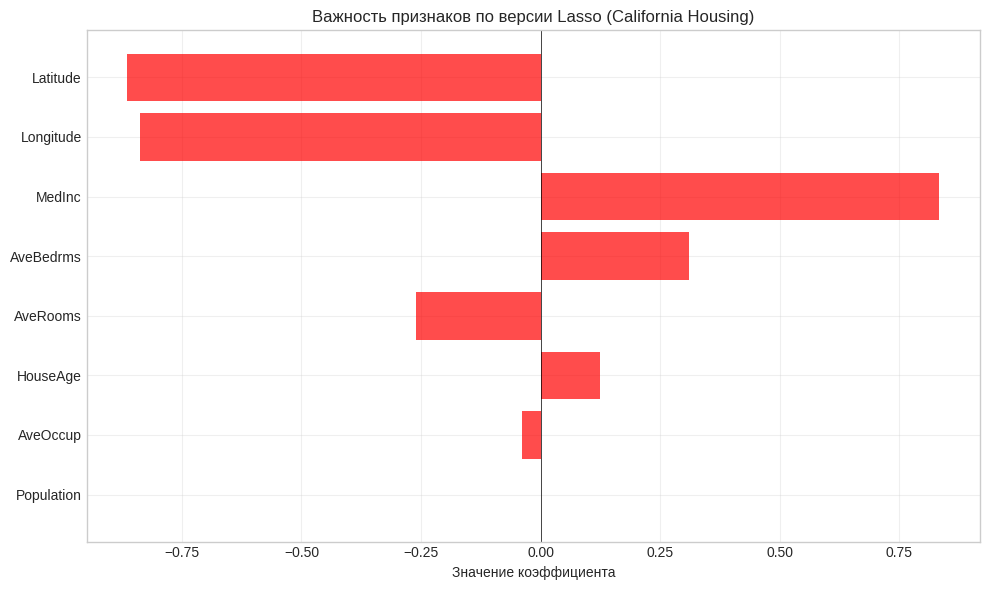

In [ ]:
# 8. Визуализация: сравнение R² на тесте
# ============================================================
plt.figure(figsize=(10, 6))
models_names = ['Linear\n(все 8 признаков)', 'SelectKBest\n(k=8)', 'Lasso']
r2_test_values = [r2_test_all, r2_test_sel, r2_test_lasso]
colors = ['blue', 'green', 'red']

bars = plt.bar(models_names, r2_test_values, color=colors, alpha=0.7)
plt.axhline(y=r2_test_all, color='blue', linestyle='--', alpha=0.5,
            label=f'Базовая линия: {r2_test_all:.4f}')
plt.ylabel('R² Score')
plt.title('Сравнение качества моделей на тестовой выборке (California Housing)')
plt.legend()
plt.grid(True, alpha=0.3)

for bar, value in zip(bars, r2_test_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{value:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================================
# 9. Визуализация: важность признаков по версии Lasso
# ============================================================
plt.figure(figsize=(10, 6))
importance_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': lasso_coefs
}).sort_values('Коэффициент', key=lambda x: np.abs(x), ascending=True)

plt.barh(importance_df['Признак'], importance_df['Коэффициент'], color='red', alpha=0.7)
plt.xlabel('Значение коэффициента')
plt.title('Важность признаков по версии Lasso (California Housing)')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Первый вывод: Lasso умеет сам находить и удалять бесполезные признаки. Ему не нужен человек, который будет гадать, какие характеристики важны, а какие нет. Он просто смотрит на данные и принимает решение.

Второй вывод: меньше признаков — не значит хуже. Иногда лишние данные только запутывают модель. Когда мы убрали население района, модель стала работать даже лучше, чем со всеми восемью признаками.

Третий вывод: SelectKBest в нашем случае не помог, потому что мы попросили его выбрать восемь признаков, а их и так было восемь. Если бы признаков было больше, он бы действительно их отобрал.

Четвёртый вывод: расположение дома и доход района — это самые важные вещи для предсказания цены. Это совпадает со здравым смыслом: в хорошем районе с богатыми соседями дома стоят дороже.

Ответ на главный вопрос задачи
Нам нужно было ответить: удалось ли сократить количество признаков без потери качества? Да, удалось. Lasso сократил число признаков с восьми до семи, и при этом качество предсказания даже немного выросло. Это отличный результат, который показывает, что автоматический отбор признаков работает.

